In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from typing import Tuple, List
import io
import re
import numpy as np
import requests
import time
import random

# Load Datasets

In [4]:
from __future__ import annotations
from typing import Tuple, List
import io
import re
import numpy as np
import requests
import time

def days_and_hours_since_2020(minutes_since_epoch) -> Tuple[int, int]:
    # Decode minutes_since_epoch → (year, month, day, hour)
    total_days, rem = divmod(int(minutes_since_epoch), 24 * 60)
    hour = rem // 60

    def _days_since_year0(y, m, d):
        days = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
        if (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0):
            days[2] = 29
        return y * 365 + y // 4 - y // 100 + y // 400 + sum(days[1:m]) + (d - 1)

    abs_days = total_days + _days_since_year0(1970, 1, 1)

    year = int(abs_days / 365.2425)
    while _days_since_year0(year + 1, 1, 1) <= abs_days:
        year += 1
    while _days_since_year0(year, 1, 1) > abs_days:
        year -= 1

    month = 1
    while month < 12 and _days_since_year0(year, month + 1, 1) <= abs_days:
        month += 1

    day = abs_days - _days_since_year0(year, month, 1) + 1

    # Day-of-year in 365-day scheme (Feb always = 28 days, Feb 29 excluded)
    days_per_month = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    doy = sum(days_per_month[1:month]) + (day - 1)   # 0-indexed

    day_index = (year - 2020) * 365 + doy
    return (day_index, hour)

# Placeholder for all data
class MeteoDataChunked:
    def _encode_days_and_hours(self):
        self.h_cos = np.zeros(len(self.timestamps))
        self.h_sin = np.zeros(len(self.timestamps))
        self.d_cos = np.zeros(len(self.timestamps))
        self.d_sin = np.zeros(len(self.timestamps))
        for i, t in enumerate(self.timestamps):
            d, h = days_and_hours_since_2020(t)
            self.h_cos[i] = np.cos(h/24 * 2 * np.pi) * np.sqrt(2)
            self.h_sin[i] = np.sin(h/24 * 2 * np.pi) * np.sqrt(2)
            self.d_cos[i] = np.cos(d/365 * 2 * np.pi) * np.sqrt(2)
            self.d_sin[i] = np.sin(d/365 * 2 * np.pi) * np.sqrt(2)

    def __init__(self, name, timestamps: np.ndarray, global_rad: np.ndarray,
                temp: np.ndarray, rel_hum: np.ndarray, pressure: np.ndarray, wind_speed: np.ndarray,
                rain: np.ndarray, cloud_cover: np.ndarray, means=None, sigmas=None):
        self.name       = name
        self.timestamps = timestamps
        if means is None or sigmas is None:
            self.global_rad  = global_rad
            self.temp        = temp
            self.pressure    = pressure
            self.rel_hum     = rel_hum
            self.wind_speed  = wind_speed
            self.rain        = rain
            self.cloud_cover = cloud_cover
        else:
            self.global_rad  = (global_rad - means[0])/sigmas[0]
            self.temp        = (temp - means[1])/sigmas[1]
            self.pressure    = (pressure - means[2])/sigmas[2]
            self.rel_hum     = (rel_hum - means[3])/sigmas[3]
            self.wind_speed  = (wind_speed - means[4])/sigmas[4]
            self.rain        = (rain - means[5])/sigmas[5]
            self.cloud_cover = (cloud_cover - means[6])/sigmas[6] 
        self._encode_days_and_hours()

    @classmethod
    def from_meteodata(cls, md: MeteoDataChunked):
        return MeteoDataChunked(md.name, md.timestamps, md.global_rad, md.temp, md.rel_hum,
                                md.pressure, md.wind_speed, md.rain, md.cloud_cover, md.means, md.sigmas)

    def __repr__(self):
        start = days_and_hours_since_2020(self.timestamps[0])
        end   = days_and_hours_since_2020(self.timestamps[-1])
        ret = f"Timestamps since {start[0]} to {end[0]}."
        return ret

    def __len__(self):
        return len(self.timestamps)

    def cut(self, start_idx: int, end_idx: int) -> MeteoDataChunked:
        if start_idx >= end_idx:
            return None
        new = MeteoDataChunked(
            self.name,
            self.timestamps[start_idx:end_idx],
            self.global_rad[start_idx:end_idx],
            self.temp[start_idx:end_idx],
            self.rel_hum[start_idx:end_idx],
            self.pressure[start_idx:end_idx],
            self.wind_speed[start_idx:end_idx],
            self.rain[start_idx:end_idx],
            self.cloud_cover[start_idx:end_idx]
        )
        return new

    @staticmethod
    def stats_from_more_chunks(chunks: List['MeteoDataChunked']) -> Tuple[np.ndarray, np.ndarray]:
        new = MeteoDataChunked(
            "NORMALIZED",
            np.concatenate([c.timestamps  for c in chunks]),
            np.concatenate([c.global_rad  for c in chunks]),
            np.concatenate([c.temp        for c in chunks]),
            np.concatenate([c.rel_hum     for c in chunks]),
            np.concatenate([c.pressure    for c in chunks]),
            np.concatenate([c.wind_speed  for c in chunks]),
            np.concatenate([c.rain        for c in chunks]),
            np.concatenate([c.cloud_cover for c in chunks]),
        )
        mean = np.array([
            new.global_rad.mean(),
            new.temp.mean(),
            new.pressure.mean(),
            new.rel_hum.mean(),
            new.wind_speed.mean(),
            new.rain.mean(),
            new.cloud_cover.mean()
        ])
        std = np.array([
            new.global_rad.std(),
            new.temp.std(),
            new.pressure.std(),
            new.rel_hum.std(),
            new.wind_speed.std(),
            new.rain.std(),
            new.cloud_cover.std()
        ])
        return mean, std
        

In [5]:
# Start with the Openmeteo data, then load the BSRN data.
NGROK_URL = "https://curtly-salvageable-clementina.ngrok-free.dev"

# Connect to the ngrok URL and retrieve data from dataset-openmeteo/saved
def load_openmeteo_data() -> List[MeteoDataChunked]:
    ret = []
    cities = ["Dunakezsi", "Pecel", "Szigetszentmiklos", "Vecses",
              "Kistarcsa", "Pomáz", "Sóskút", "Martonvásár"]
    for c in cities:
        response = requests.get(f"{NGROK_URL}/dataset-openmeteo/saved/{c}.npz")
        data = np.load(io.BytesIO(response.content))
        ret.append(MeteoDataChunked(c, data["timestamps"],    data["global_tilted_irradiance"],
                                    data["temperature_2m"],   data["relative_humidity_2m"],
                                    data["surface_pressure"], data["wind_speed_10m"],
                                    data["rain"],             data["cloud_cover"]))
    return ret

def load_bsrn_data() -> List[MeteoDataChunked]:
    base_url = f"{NGROK_URL}/dataset-bsrn/saved"

    def list_files() -> List[str]:
        html = requests.get(base_url).text
        return re.findall(r'href="([^"/?][^"]*)"', html)

    ret = []
    files = list_files()
    for f in files:
        if f == "dates.txt":
            continue
        response = requests.get(f"{base_url}/{f}")
        data = np.load(io.BytesIO(response.content))
        # Get the chunk number rn
        number = int((f[5:])[0:-4])
        # Get the budapest wind speed
        response = requests.get(f"{NGROK_URL}/dataset-openmeteo/saved/Budapest{number}.npz")
        data_openmeteo = np.load(io.BytesIO(response.content))
        wind_speed = data_openmeteo["wind_speed_10m"]

        ret.append(MeteoDataChunked("BSRN", data["timestamps"],  data["global_rad"],
                                            data["temperature"], data["humidity"],
                                            data["pressure"],    wind_speed,
                                            None, None))
        # Stupid ngrok max reqs hack
        time.sleep(1)
    
    return ret

openmeteo_chunks = load_openmeteo_data()
#bsrn_chunks      = load_bsrn_data()

# Data Loaded, create PyTorch Dataset

In [7]:
# The sliding window length
CONSECUTIVE_HOURS       = 4 * 24 # 4 days
CONSECUTIVE_HOURS_AFTER = 2 * 24 # 2 days
TEST_FRACTION           = 0.20

# Create train and testing data. Merge them and compute mean and stds.
# First, process the openmeteo data. BSRN will be used for tinetuning.
def create_train_and_test_chunks(chunks):
    """
    Use cross validation to split the loaded dataset in `chunks`
    to train and test data.
    Compute mean and standard deviation from the training data
    and use this to normalize the training and testing data set.

    Returns:
        normalized train chunks
        normalized test chunks
        mean for all input data vectors
        sigmas for all input data vectors 
    """
    n = len(chunks)
    TRAIN_TO_TEST = int(1/TEST_FRACTION)

    all_train_data,   all_train_labels = [], []
    all_test_data,    all_test_labels  = [], []

    train_data = []
    test_data  = []

    # Perform cross validation on more chunks. From this, compute train statistics (mean, std).
    for i, c in enumerate(chunks):
        L = len(c.timestamps)
        if len(c.timestamps)/TRAIN_TO_TEST >= (CONSECUTIVE_HOURS + CONSECUTIVE_HOURS_AFTER):
            # Slice the data first.
            test_start = int((1.0 - ((i % TRAIN_TO_TEST) + 1) * TEST_FRACTION) * L)
            test_end   = int((1.0 -  (i % TRAIN_TO_TEST)      * TEST_FRACTION) * L)
            # Slice before
            before = c.cut(0, test_start)
            if before is not None:
                train_data.append(c.cut(0, test_start))
            # Slide test data
            between = c.cut(test_start, test_end)
            if between is not None:
                test_data.append(c.cut(test_start, test_end))
            # Slide train data after
            after = c.cut(test_end, L)
            if after is not None:
                train_data.append(after)
        else:
            # The testing data would be too small. Just append everything to training
            train_data.append(c)

    meteo_train_means, meteo_train_sigmas = MeteoDataChunked.stats_from_more_chunks(train_data)
    print(f"Training data computed means: {meteo_train_means}, sigmas: {meteo_train_sigmas}")
    
    # Perform normalization
    train_data_normalized = []; test_data_normalized = []
    for c in train_data:
        c.means  = meteo_train_means
        c.sigmas = meteo_train_sigmas
        train_data_normalized.append(MeteoDataChunked.from_meteodata(c))
    for c in test_data:
        c.means  = meteo_train_means
        c.sigmas = meteo_train_sigmas
        test_data_normalized.append(MeteoDataChunked.from_meteodata(c))

    return train_data_normalized, test_data_normalized, meteo_train_means, meteo_train_sigmas

openmeteo_train_chunks, openmeteo_test_chunks, openmeteo_mu, openmeteo_sigma = create_train_and_test_chunks(openmeteo_chunks)
#bsrn_train_chunks, bsrn_test_chunks, bsrn_mu, bsrn_sigma = create_train_and_test_chunks(bsrn_chunks)

Training data computed means: [1.82977533e+02 1.20660583e+01 1.00069019e+03 7.10206216e+01
 1.03877820e+01 6.77911788e-02 5.74299444e+01], sigmas: [272.61952811   9.07544945   8.85478782  19.44643843   5.66705239
   0.36759236  41.84228656]


In [12]:
WEATHER_VARIABLES = 6
DECODER_FEATURES = 7

# Now, create sliding windows from such data and data PyTorch data loaders
def create_dataloader(chunks_normalized: List[MeteoDataChunked], cons_hours, cons_hours_after, batch_size=32, shuffle=True):
    """
    Create sliding windows from every chunk from chunks_normalized.
    Returns (data: (N, cons_hours, 8), labels: (N, cons_hours)),
    where N is the number of sliding windows created
    """
    # cos(h), sin(h), cos(d), sin(d), GTI(i-1), temp, pressure, hum, wind_speed, rain, cloud_cover
    N_FEATURES = 11 

    N = 0
    for c in chunks_normalized:
        N += len(c.timestamps) - (cons_hours + cons_hours_after)

    # Add temperature to the teach enforcing
    data_prior = np.zeros((N, cons_hours, N_FEATURES), dtype=np.float32)                               # Encoder input data
    teach_enf  = np.zeros((N, cons_hours_after, DECODER_FEATURES), dtype=np.float32)                   # Inputs for the decoder input for teacher enforcing
    labels_exp = np.zeros((N, cons_hours_after), dtype=np.float32)                                     # Expected labels for the decoder output
    timestamps = np.zeros((N, cons_hours), dtype=np.float32)                                           # Timestamp marks. Not needed, only for later use.

    i = 0
    for c in chunks_normalized:
        for j in range(1, len(c.timestamps) - cons_hours - cons_hours_after + 1):
            data_prior[i, :, :] = np.vstack([
                c.h_cos[j:j+cons_hours], c.h_sin[j:j+cons_hours], c.d_cos[j:j+cons_hours],
                c.d_sin[j:j+cons_hours], c.global_rad[j-1:j-1+cons_hours], c.temp[j:j+cons_hours],
                c.pressure[j:j+cons_hours], c.rel_hum[j:j+cons_hours], c.wind_speed[j:j+cons_hours],
                c.rain[j:j+cons_hours], c.cloud_cover[j:j+cons_hours]]).T
            teach_enf[i, :, :]  = np.vstack([
                c.h_cos[j+cons_hours:j+cons_hours+cons_hours_after], c.h_sin[j+cons_hours:j+cons_hours+cons_hours_after],
                c.d_cos[j+cons_hours:j+cons_hours+cons_hours_after], c.d_sin[j+cons_hours:j+cons_hours+cons_hours_after],
                c.global_rad[j+cons_hours-1:j+cons_hours+cons_hours_after-1],
                c.temp[j+cons_hours:j+cons_hours+cons_hours_after],
                c.cloud_cover[j+cons_hours:j+cons_hours+cons_hours_after]]).T
            labels_exp[i, :] = c.global_rad[j+cons_hours:j+cons_hours+cons_hours_after]
            timestamps[i, :] = c.timestamps[j:j+cons_hours]
            i += 1

    ds = TensorDataset(torch.from_numpy(data_prior), torch.from_numpy(teach_enf), torch.from_numpy(labels_exp),
                       torch.from_numpy(timestamps))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=6)
    return loader

print("Creating dataloaders")
openmeteo_train_loader = create_dataloader(openmeteo_train_chunks, CONSECUTIVE_HOURS, CONSECUTIVE_HOURS_AFTER)
print("Openmeteo train loader created!")
openmeteo_test_loader  = create_dataloader(openmeteo_test_chunks,  CONSECUTIVE_HOURS, CONSECUTIVE_HOURS_AFTER, shuffle=False)
print("Openmeteo test loader created!")

Creating dataloaders
Openmeteo train loader created!
Openmeteo test loader created!


# GRU PyTorch

In [ ]:
%run -i solar_seq2seq_gru

LEARNING_RATE = 1e-4
EPOCHS = 2


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available device is", DEVICE)
if DEVICE.type != "cuda":
    print("You need to use cuda or you will bore yourself to death.")

def seq2seq_train(model: nn.Module,
                  loss_fn: nn.modules.loss._Loss,
                  optimizer: torch.optim.Optimizer,
                  train_loader: DataLoader,
                  epoch: int=0) -> List[float]:
    n_iters = len(train_loader)
    model.train()
    train_loss = [0] * n_iters
    for batch_idx, (encoder_in, decoder_in, labels, _) in enumerate(train_loader):
        encoder_in, decoder_in, labels = encoder_in.to(DEVICE), decoder_in.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        output = model(encoder_in, decoder_in)
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()

        if batch_idx % max(1, n_iters // 8) == 0:
            print(f'Epoch {epoch}: [{batch_idx*len(encoder_in)}/{len(train_loader.dataset)}] Loss: {loss.item():.3f}')

        train_loss[batch_idx] = loss.item()

    return train_loss


def seq2seq_test(model: nn.Module,
                 loss_fn: nn.modules.loss._Loss,
                 test_loader: DataLoader) -> float:
    test_loss = 0
    
    model.eval()
    with torch.no_grad():
        for encoder_in, decoder_in, labels, _ in test_loader:
            encoder_in, decoder_in, labels = encoder_in.to(DEVICE), decoder_in.to(DEVICE), labels.to(DEVICE)
            output = model(encoder_in, decoder_in)
            test_loss += loss_fn(output, labels).item()

    return test_loss

model = SolarSeq2SeqGRU()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.HuberLoss()
losses = []

for epoch in range(EPOCHS):
    l = seq2seq_train(model, criterion, optimizer, openmeteo_train_loader, epoch)
    losses.append(l)
    loss_test_total = seq2seq_test(model, criterion, openmeteo_test_loader)
    print(f"Finished epoch {epoch}. Loss = {loss_test_total}")


Available device is cpu
You need to use cuda or you will bore yourself to death.
Epoch 0: [0/334511] Loss: 0.407
Epoch 0: [41792/334511] Loss: 0.028
Epoch 0: [83584/334511] Loss: 0.020
Epoch 0: [125376/334511] Loss: 0.014
Epoch 0: [167168/334511] Loss: 0.012
Epoch 0: [208960/334511] Loss: 0.014
Epoch 0: [250752/334511] Loss: 0.012
Epoch 0: [292544/334511] Loss: 0.010
Epoch 0: [334336/334511] Loss: 0.012
Finished epoch 0. Loss = 49.6741875289008
Epoch 1: [0/334511] Loss: 0.010
Epoch 1: [41792/334511] Loss: 0.009
Epoch 1: [83584/334511] Loss: 0.012
Epoch 1: [125376/334511] Loss: 0.010
Epoch 1: [167168/334511] Loss: 0.011
Epoch 1: [208960/334511] Loss: 0.013
Epoch 1: [250752/334511] Loss: 0.012
Epoch 1: [292544/334511] Loss: 0.011
Epoch 1: [334336/334511] Loss: 0.010
Finished epoch 1. Loss = 44.527715355332475
Epoch 2: [0/334511] Loss: 0.010
Epoch 2: [41792/334511] Loss: 0.009
Epoch 2: [83584/334511] Loss: 0.009
Epoch 2: [125376/334511] Loss: 0.013
Epoch 2: [167168/334511] Loss: 0.011
Epo

In [18]:
torch.save(model.state_dict(), "solar_gru_weights.pth")

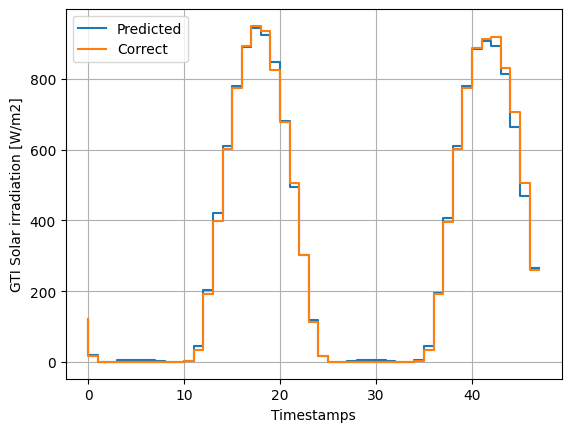

In [62]:
import os
import random


def _postprocess_preds(predictions: np.ndarray) -> np.ndarray:
    """
    Postprocess predictions. Any negative value is rounded to zero.
    TODO: clip positive values during nighttime.
    """
    return np.where(predictions < 0, 0, predictions)

def _seq2seq_inference(
    model: nn.Module,
    prior_data: torch.Tensor,
    decoder_extra_data: torch.Tensor,
    timestamps: torch.Tensor,
    minute_step=60) -> np.ndarray:
    """
    Perform inference using the seq2seq gru model.
    Automatically computes timestamps for the prediction, based on the last data from prior.
    The default minute step is 60, but can be changed if the data is different.
    Arguments:
        prior:       prior knowledge, the same format used in training, testing.
        minute_step: minute step
    """
    batch_size = prior_data.shape[0]
    tslast = timestamps[:, -1].numpy()  # (batch,)

    d_cos = np.zeros((batch_size, CONSECUTIVE_HOURS_AFTER), dtype=np.float32)
    d_sin = np.zeros((batch_size, CONSECUTIVE_HOURS_AFTER), dtype=np.float32)
    h_cos = np.zeros((batch_size, CONSECUTIVE_HOURS_AFTER), dtype=np.float32)
    h_sin = np.zeros((batch_size, CONSECUTIVE_HOURS_AFTER), dtype=np.float32)
    dummy = np.zeros((batch_size, CONSECUTIVE_HOURS_AFTER), dtype=np.float32)  # GTI placeholder, ignored in eval
    temp  = np.zeros((batch_size, CONSECUTIVE_HOURS_AFTER), dtype=np.float32)
    cl_c  = np.zeros((batch_size, CONSECUTIVE_HOURS_AFTER), dtype=np.float32)

    for b in range(batch_size):
        for i in range(CONSECUTIVE_HOURS_AFTER):
            ts = tslast[b] + (i + 1) * minute_step
            d, h = days_and_hours_since_2020(ts)
            d_cos[b, i] = np.cos(d/365 * 2 * np.pi) * np.sqrt(2)
            d_sin[b, i] = np.sin(d/365 * 2 * np.pi) * np.sqrt(2)
            h_cos[b, i] = np.cos(h/24 * 2 * np.pi) * np.sqrt(2)
            h_sin[b, i] = np.sin(h/24 * 2 * np.pi) * np.sqrt(2)
            temp[b, i]  = decoder_extra_data[b, i, 5]
            cl_c[b, i]  = decoder_extra_data[b, i, 6]

    # Stack to (batch, cons_hours_after, 5)
    decoder_in = torch.from_numpy(np.stack([h_cos, h_sin, d_cos, d_sin, dummy, temp, cl_c], axis=2)).to(DEVICE)
    prior_data = prior_data.to(DEVICE)

    model.eval()
    with torch.no_grad():
        return model(prior_data, decoder_in).detach().cpu().numpy()  # (batch, cons_hours_after)

def get_infered_data(
    model: nn.Module,
    data_loader: DataLoader,
    dataset_mu,
    dataset_sigma,
    minute_step=60) -> Tuple[np.ndarray, np.ndarray]:

    # Get random batch from test loader.
    # Technically, i shouldn't get decoder data, but I have extra meteo variables ready.
    encoder_in, decoder_in, correct_labels, timestamps = random.choice(list(iter(data_loader)))
    predictions = model.forecast(encoder_in, decoder_in, DEVICE)
    if predictions is None:
        return None, None
    predictions = predictions * dataset_sigma[0] + dataset_mu[0]
    #predictions    = _seq2seq_inference(model, encoder_in, decoder_in, timestamps) * dataset_sigma[0] + dataset_mu[0]
    correct_labels = correct_labels.numpy() * dataset_sigma[0] + dataset_mu[0]

    # Return first sample from batch
    return predictions[0], correct_labels[0]

def compute_accuracy(model, loader, dataset_mu, dataset_sigma, minute_step=60):
    def smape(y_true, y_pred):
        return 1/y_true.shape[1] * np.sum(2* np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)), axis=1)
    # Mean absolute percentage error
    MAPEs = []
    power_percentage_errors = []
    for i, (encoder_in, decoder_in, correct_labels, timestamps) in enumerate(loader):
        if i > 100:
            break
        c_labels = (correct_labels * dataset_sigma[0] + dataset_mu[0]).numpy()
        preds = _postprocess_preds(_seq2seq_inference(model, encoder_in, decoder_in, timestamps) * dataset_sigma[0] + dataset_mu[0])
        # Compute the power output errors (it's in kWh)
        correct_power_kwh = np.sum(c_labels, axis=1) * 60 / minute_step / 1000
        preds_power_kwh   = np.sum(preds, axis=1)            * 60 / minute_step / 1000
        kwh_errors = np.abs((correct_power_kwh - preds_power_kwh) / correct_power_kwh)

        # Compute MAPEs
        MAPEs.extend(smape(c_labels, preds))
        power_percentage_errors.extend(kwh_errors)

    return np.array(MAPEs), np.array(power_percentage_errors)

script_dir = os.path.dirname(os.path.realpath(__file__))    
weights_path = os.path.join(script_dir, "solar_gru_weights.pth")
if not os.path.exists(weights_path):
    raise FileNotFoundError("solar_gru_weights.pth not found next to solar_gru.ipnyb!")

model_weights = torch.load(weights_path, map_location="cpu")
#model.set_weights(model_weights)

#MAPEs, kwh_total_errors = compute_accuracy(model, openmeteo_test_loader, openmeteo_mu, openmeteo_sigma)
#print(np.sum(kwh_total_errors < 0.3)/len(kwh_total_errors))

openmeteo_preds, openmeteo_correct_labels = get_infered_data(model, openmeteo_test_loader, openmeteo_mu, openmeteo_sigma)
plt.step(range(len(openmeteo_preds)), _postprocess_preds(openmeteo_preds), label="Predicted")
plt.step(range(len(openmeteo_correct_labels)), openmeteo_correct_labels, label="Correct")
plt.xlabel("Timestamps")
plt.ylabel("GTI Solar irradiation [W/m2]")
plt.grid()
plt.legend()
